IMPORTED CODE

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import PIL
%matplotlib inline

In [2]:
def show_img_compar(img_1, img_2 ):
    f, ax = plt.subplots(1, 2, figsize=(10,10))
    ax[0].imshow(img_1)
    ax[1].imshow(img_2)
    ax[0].axis('off')
    ax[1].axis('off')
    f.tight_layout()
    plt.show()

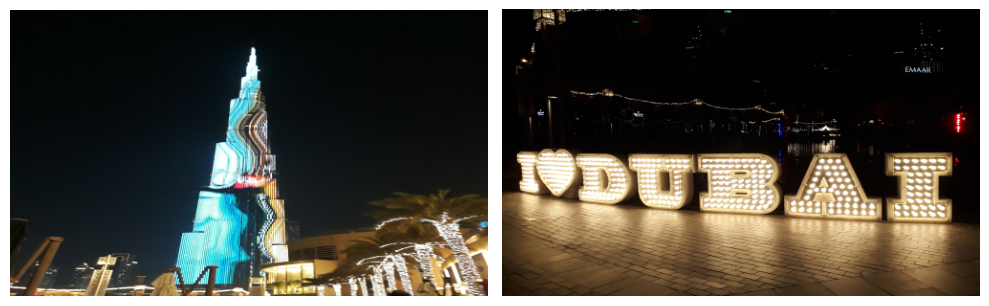

In [3]:
img = cv.imread("img/img_1.jpg")
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
img_2 = cv.imread("img/img_2.jpg")
img_2 = cv.cvtColor(img_2, cv.COLOR_BGR2RGB)

dim = (500, 300)
# resize image
img = cv.resize(img, dim, interpolation = cv.INTER_AREA)
img_2 = cv.resize(img_2, dim, interpolation = cv.INTER_AREA)

show_img_compar(img, img_2)

In [4]:
from sklearn.cluster import KMeans

In [5]:
clt = KMeans(n_clusters=5)
clt.fit(img.reshape(-1, 3))

KMeans(n_clusters=5)

In [6]:
clt.labels_

array([1, 1, 1, ..., 3, 3, 3])

In [7]:
clt.cluster_centers_

array([[ 77.65757191, 202.44500846, 216.70875635],
       [  9.84241478,  14.67104696,  16.31277596],
       [162.1086582 , 135.87604997,  96.18307129],
       [ 62.65238909,  56.78489157,  44.55241609],
       [215.38533091, 229.27958944, 215.52026088]])

In [8]:
def palette(clusters):
    width=300
    palette = np.zeros((50, width, 3), np.uint8)
    steps = width/clusters.cluster_centers_.shape[0]
    for idx, centers in enumerate(clusters.cluster_centers_): 
        palette[:, int(idx*steps):(int((idx+1)*steps)), :] = centers
    return palette

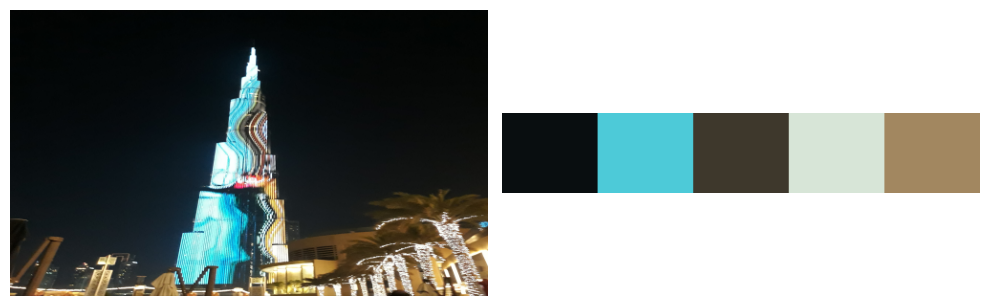

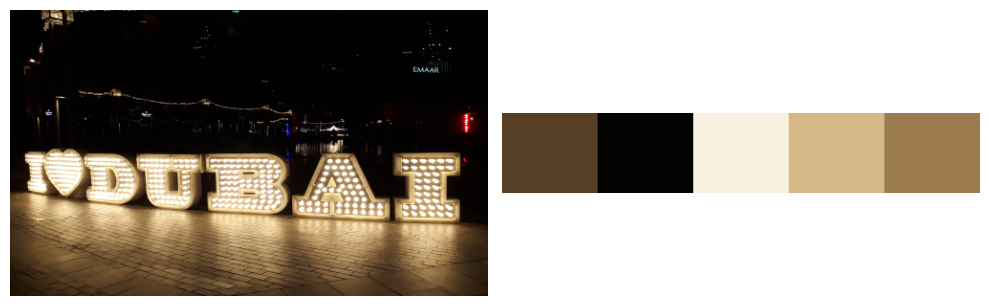

In [9]:
clt_1 = clt.fit(img.reshape(-1, 3))
show_img_compar(img, palette(clt_1))

clt_2 = clt.fit(img_2.reshape(-1, 3))
show_img_compar(img_2, palette(clt_2))

In [10]:
from collections import Counter

def palette_perc(k_cluster):
    width = 300
    palette = np.zeros((50, width, 3), np.uint8)
    
    n_pixels = len(k_cluster.labels_)
    counter = Counter(k_cluster.labels_) # count how many pixels per cluster
    perc = {}
    for i in counter:
        perc[i] = np.round(counter[i]/n_pixels, 2)
    perc = dict(sorted(perc.items()))
    
    #for logging purposes
    print(perc)
    print(k_cluster.cluster_centers_)
    
    step = 0
    
    for idx, centers in enumerate(k_cluster.cluster_centers_): 
        palette[:, step:int(step + perc[idx]*width+1), :] = centers
        step += int(perc[idx]*width+1)
        
    return palette

{0: 0.7, 1: 0.06, 2: 0.06, 3: 0.15, 4: 0.03}
[[  9.85392936  14.68474203  16.32797932]
 [215.39191357 229.29457696 215.54444326]
 [162.19594522 135.97185377  96.25730616]
 [ 62.79092836  56.86401551  44.57297444]
 [ 77.67223514 202.44745189 216.70945232]]


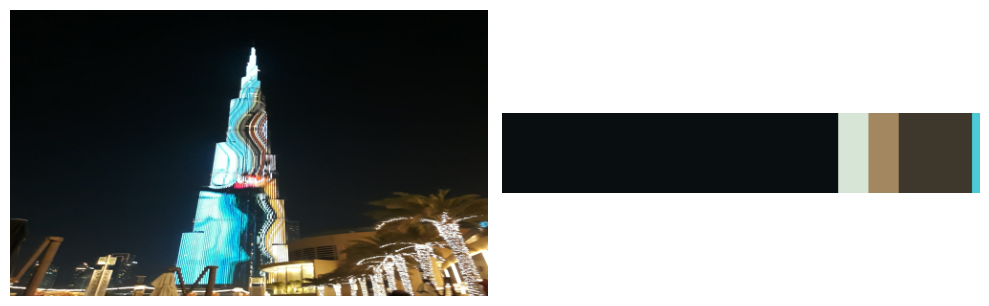

{0: 0.05, 1: 0.55, 2: 0.12, 3: 0.11, 4: 0.17}
[[248.94496796 242.99937178 226.11735143]
 [  5.41502561   3.04362707   2.39430611]
 [158.17312938 125.07653634  80.41851634]
 [215.30632131 186.30878816 137.64650015]
 [ 88.40569465  63.90340415  38.80609746]]


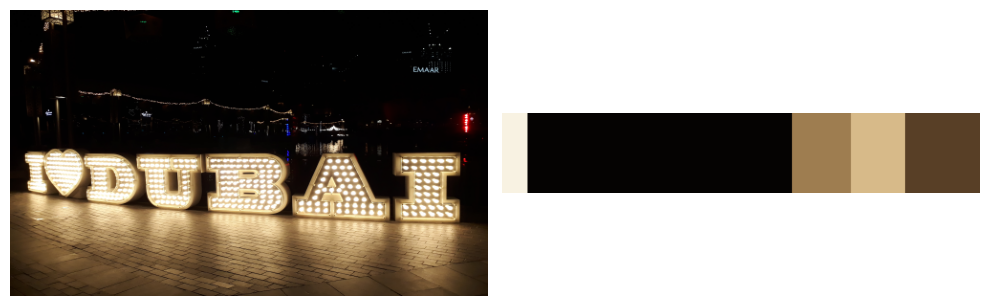

In [11]:
clt_1 = clt.fit(img.reshape(-1, 3))
show_img_compar(img, palette_perc(clt_1))

clt_2 = clt.fit(img_2.reshape(-1, 3))
show_img_compar(img_2, palette_perc(clt_2))

In [12]:
#LEFT ABOVE ALONE FOR REFRENCE STARTING HERE

In [13]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import PIL

# Ensure matplotlib plots appear inline
%matplotlib inline

from sklearn.cluster import KMeans

In [14]:
def show_img_compar(img_1, img_2):
    f, ax = plt.subplots(1, 2, figsize=(10, 10))
    ax[0].imshow(img_1)
    ax[1].imshow(img_2)
    ax[0].axis('off')
    ax[1].axis('off')
    f.tight_layout()
    plt.show()

In [15]:
img = cv.imread("img/img_1.jpg")
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

img_2 = cv.imread("img/img_2.jpg")
img_2 = cv.cvtColor(img_2, cv.COLOR_BGR2RGB)


# Resize images
img = cv.resize(img, dim, interpolation=cv.INTER_AREA)
img_2 = cv.resize(img_2, dim, interpolation=cv.INTER_AREA)

# Show image comparison
# show_img_compar(img, img_2)

In [16]:
from collections import Counter

def palette_perc(k_cluster):
    width = 300
    palette = np.zeros((50, width, 3), np.uint8)
    
    n_pixels = len(k_cluster.labels_)
    counter = Counter(k_cluster.labels_) # count how many pixels per cluster
    perc = {}
    for i in counter:
        perc[i] = np.round(counter[i]/n_pixels, 2)
    perc = dict(sorted(perc.items()))
    
    #for logging purposes
    print(perc)
    print(k_cluster.cluster_centers_)
    
    step = 0
    
    for idx, centers in enumerate(k_cluster.cluster_centers_): 
        palette[:, step:int(step + perc[idx]*width+1), :] = centers
        step += int(perc[idx]*width+1)
        
    return palette

In [17]:
# Perform KMeans clustering on the images
clt_1 = KMeans(n_clusters=3)
clt_1 = clt_1.fit(img.reshape(-1, 3))

clt_2 = KMeans(n_clusters=3)
clt_2 = clt_2.fit(img_2.reshape(-1, 3))

In [18]:
# Define function for resampling labels and centers
def resample(labels, centers):
    resamp = []
    # Iterate over labels and assign corresponding color from centers
    for p in labels:
        resamp.append(centers[p])
    # Convert list to np array with original shape
    res = np.array(resamp).reshape((dim[1], dim[0], 3))
    # Display the resampled image with RGB values between 0 and 1
    plt.imshow(res/255.0)

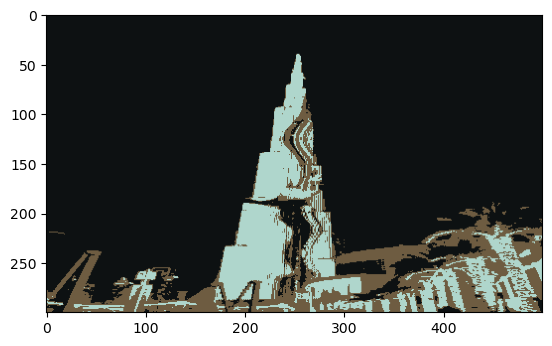

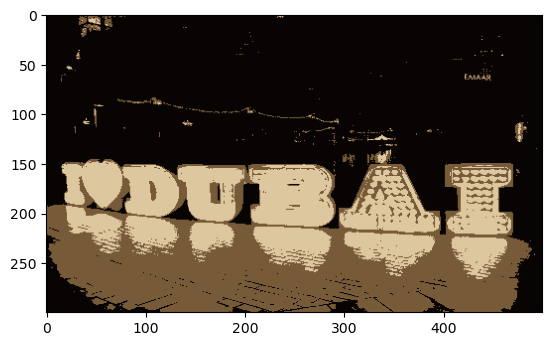

In [19]:
# Resample and display the first image
resample(clt_1.labels_, clt_1.cluster_centers_)
plt.show()

# Resample and display the second image
resample(clt_2.labels_, clt_2.cluster_centers_)
plt.show()

COLOR ISOLATION

{0: 0.78, 1: 0.11, 2: 0.12}
[[ 13.47402196  17.91272306  18.80604839]
 [175.21225424 214.44726104 204.23061704]
 [110.20033592  92.71637901  65.54193212]]


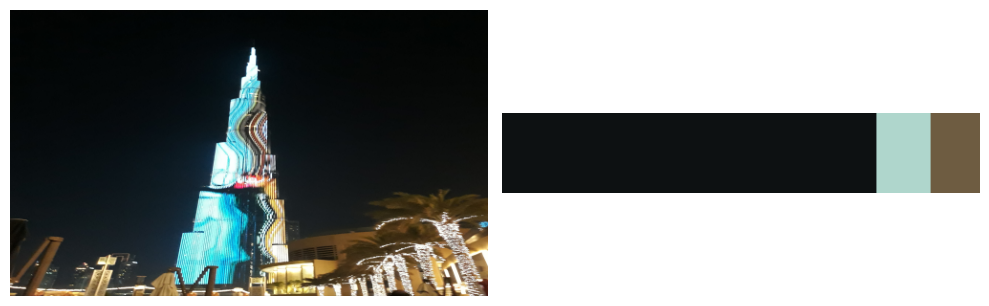

In [20]:
clt2 = KMeans(n_clusters=3)
clt2.fit(img.reshape(-1, 3))

clt2 = clt2.fit(img.reshape(-1, 3))
show_img_compar(img, palette_perc(clt2))

In [21]:
def isolate_color(labels, centers, color_idx, fill_idx):
    resamp = []
    # what is the label for this pixel
    for p in labels:
        if p == color_idx:
            # put the color for that label into the resample
            resamp.append(centers[p])
        else:
            resamp.append(centers[fill_idx])
    
    # convert the list to np array of original shape (w, h, & 3 for rgb)
    res = np.array(resamp).reshape((dim[1], dim[0], 3))
    # show the image with rgb values between 0 and 1
    plt.imshow(res / 255.0)

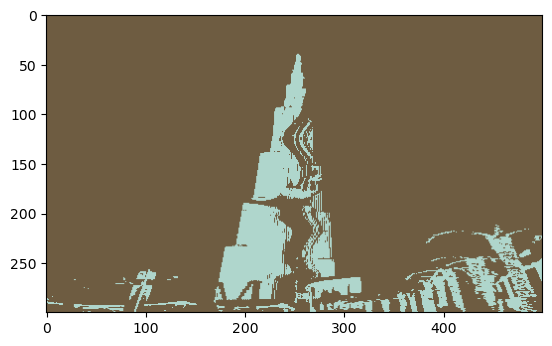

In [22]:
isolate_color(clt_1.labels_, clt_1.cluster_centers_, 2, 1)

{0: 0.05, 1: 0.04, 2: 0.53, 3: 0.02, 4: 0.03, 5: 0.1, 6: 0.22, 7: 0.02}
[[147.30051963 119.50317552  81.29272517]
 [232.80069994 240.42475594 230.78578007]
 [  6.64213252  10.64056598  11.59398648]
 [ 45.20817981 187.96904937 209.53242447]
 [198.27502392 181.68688995 145.03062201]
 [ 74.97019613  62.18133594  42.97822294]
 [ 23.43547299  31.00150205  34.38529213]
 [138.80861111 227.80972222 230.31388889]]


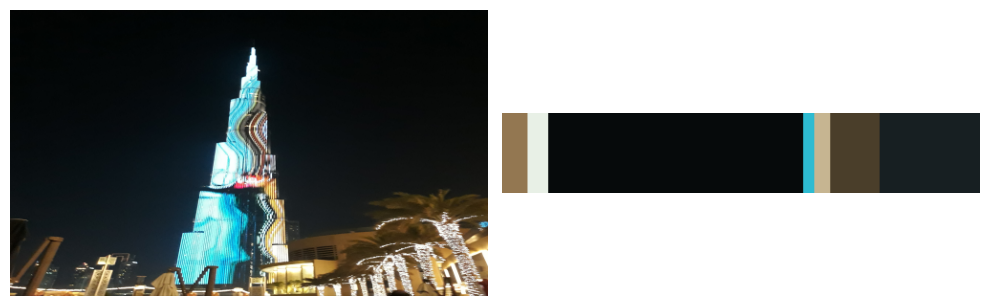

In [23]:
clt2 = KMeans(n_clusters=8)
clt2.fit(img.reshape(-1, 3))

clt2 = clt2.fit(img.reshape(-1, 3))
show_img_compar(img, palette_perc(clt2))

In [25]:
#isolate_color(clt_2.labels_, clt_2.cluster_centers_, 6, 5)

MAPPING COLORS

In [26]:
from collections import Counter

def palette_perc(k_cluster):
    width = 300
    palette = np.zeros((50, width, 3), np.uint8)
    
    n_pixels = len(k_cluster.labels_)
    counter = Counter(k_cluster.labels_)  # count how many pixels per cluster
    perc = {}
    for i in counter:
        perc[i] = np.round(counter[i] / n_pixels, 2)
    perc = dict(sorted(perc.items()))
    
    # for logging purposes
    print(perc)
    print(k_cluster.cluster_centers_)
    
    step = 0
    
    for idx, centers in enumerate(k_cluster.cluster_centers_): 
        palette[:, step:int(step + perc[idx] * width + 1), :] = centers
        step += int(perc[idx] * width + 1)
        
    return palette, perc

{0: 0.78, 1: 0.11, 2: 0.12}
[[ 13.48172515  17.92002985  18.81155591]
 [175.16931446 214.43110589 204.23935217]
 [110.29503538  92.75205893  65.52928895]]


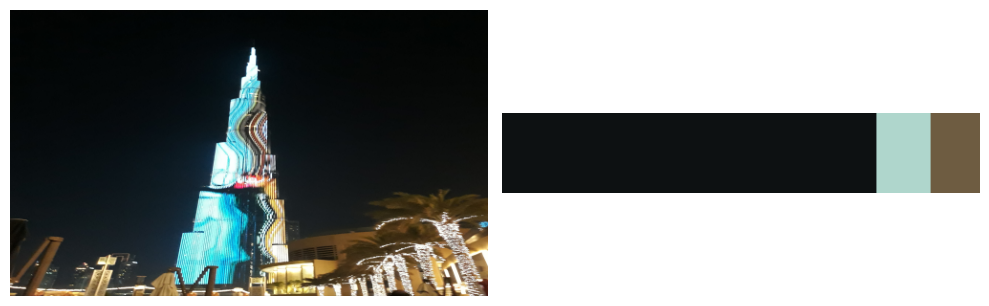

{0: 0.24, 1: 0.57, 2: 0.18}
[[119.99246766  90.87181377  56.69971617]
 [  8.07399589   4.94976862   3.50412313]
 [221.78545897 199.14647898 159.70777905]]


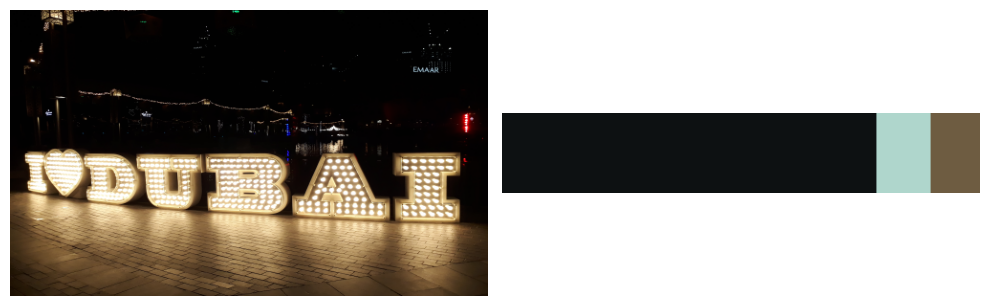

In [27]:
# this will allow me to keep the number of clusters the same for both images. 
nc = 3
clt1 = KMeans(n_clusters=nc)  # use nc here
clt_1 = clt1.fit(img.reshape(-1, 3))
pal, perc = palette_perc(clt_1)
show_img_compar(img, pal)

clt2 = KMeans(n_clusters=nc)  # use nc here
clt2.fit(img_2.reshape(-1, 3))
pal2, perc2 = palette_perc(clt_2)
show_img_compar(img_2, pal)


In [28]:
# for replacement colors
perc = perc  # get all values  
# Get associated keys
keys = list(range(len(perc)))  # create a list of indices as keys

perc2 = perc2  # get all values  
# Get associated keys 2
keys = list(range(len(perc2)))  # create a list of indices as keys

# sort the percentages so they are in the same order 
sort_perc = sorted(perc)
sort_perc2 = sorted(perc2)

for i in range(len(sort_perc)):
    r_idx = perc.index(sort_perc[i])  # find repl perc 
    t_idx = perc2.index(sort_perc2[i])  # find targ perc 
    r_ki = keys[r_idx]  # find original key index
    t_k = perc2.index(sort_perc2[i])  # find targ key index
    r_color = clt_1.cluster_centers_[r_ki]  # find replacement color 
    clt_2.cluster_centers_[t_idx] = r_color  # replace color in place on target list

AttributeError: 'dict' object has no attribute 'index'

In [ ]:
def transfer(labels, centers):
    resamp = []
    # what is the label for this pixel
    for p in labels:
        # put the color for that label into the resample
        resamp.append(centers[p])
    # convert the list to np array of original shape (w, h, & 3 for rgb)
    res = np.array(resamp).reshape((dim[1], dim[0], 3))
    # show the image with rgb values between 0 and 1
    plt.imshow(res / 255.0)

In [ ]:
transfer(clt_2.labels_, clt_1.cluster_centers_)

SAVE THE RESULTS

In [ ]:
def transfer(labels, centers):
    resamp = []
    for p in labels:
        resamp.append(centers[p])
    res = np.array(resamp).reshape((dim[1], dim[0], 3))
    plt.imshow(res/255.0)
    return res

In [ ]:
transfer_img = transfer(clt_2.labels_, clt_1.cluster_centers_)

In [ ]:
img = cv.cvtColor(transfer_img.astype('uint8'), cv.COLOR_RGB2BGR)
cv.imwrite("Transfer.png", img)

HOMEWORK

In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from collections import Counter
from IPython.display import display
import ipywidgets as widgets
from PIL import Image
from IPython.display import display, clear_output

In [3]:
def show_img_compar(img_1, img_2):
    f, ax = plt.subplots(1, 2, figsize=(10, 10))
    ax[0].imshow(img_1)
    ax[1].imshow(img_2)
    ax[0].axis('off')
    ax[1].axis('off')
    f.tight_layout()
    plt.show()

In [4]:
def open_image():
    filename = filedialog.askopenfilename()
    if filename:
        return filename
    else:
        return None

In [5]:
def resize_image(img, dim):
    return cv.resize(img, dim, interpolation=cv.INTER_AREA)

In [6]:
def perform_kmeans_clustering(image, n_clusters):
    # Convert the image to a NumPy array
    image_array = np.array(image)
    # Reshape the array if needed
    if len(image_array.shape) == 3:
        image_array = image_array.reshape((-1, 3))
    # Perform KMeans clustering
    clt = KMeans(n_clusters=n_clusters)
    return clt.fit(image_array)

In [7]:
def get_palette_percentage(k_cluster):
    width = 300
    palette = np.zeros((50, width, 3), np.uint8)
    
    n_pixels = len(k_cluster.labels_)
    counter = Counter(k_cluster.labels_)  # count how many pixels per cluster
    perc = {}
    for i in counter:
        perc[i] = np.round(counter[i] / n_pixels, 2)
    perc = dict(sorted(perc.items()))
    
    step = 0
    for idx, centers in enumerate(k_cluster.cluster_centers_): 
        palette[:, step:int(step + perc[idx] * width + 1), :] = centers
        step += int(perc[idx] * width + 1)
        
    return palette


In [8]:
def isolate_color(labels, centers, color_idx, fill_idx, dim):
    resamp = []
    for p in labels:
        if p == color_idx:
            resamp.append(centers[p])
        else:
            resamp.append(centers[fill_idx])
    res = np.array(resamp).reshape((dim[1], dim[0], 3))
    plt.imshow(res / 255.0)

In [22]:
def transfer_colors(img_1, img_2):
    # Ensure that both images have the same dimensions
    assert img_1.shape == img_2.shape, "Both images must have the same dimensions"
    
    resamp = []
    for i in range(img_1.shape[0]):
        for j in range(img_1.shape[1]):
            resamp.append(img_1[i, j])
    return np.array(resamp).reshape(img_2.shape)


In [23]:
def save_image(img, filename):
    img = cv.cvtColor(img.astype('uint8'), cv.COLOR_RGB2BGR)
    cv.imwrite(filename, img)

HELP With This 

# Function to handle file uploads and resizing
def handle_upload(change):
    uploaded_files = change['new']
    for name, uploaded_file in uploaded_files.items():
        content = uploaded_file['content']
        img = cv.imdecode(np.frombuffer(content, np.uint8), -1)
        img = cv.cvtColor(img, cv.COLOR_BGR2RGB)  # Convert BGR to RGB
        img = resize_image(img, dim)  # Resize image
        if name == 'image1':
            img_1.value = cv.imencode('.png', img)[1].tobytes()
        elif name == 'image2':
            img_2.value = cv.imencode('.png', img)[1].tobytes()

# Create a file uploader widget
uploader = widgets.FileUpload(
    accept='.jpg, .jpeg, .png',  # Accept image files
    multiple=True  # Allow uploading two images
)

# Create image widgets to display the uploaded images
img_1 = widgets.Image(format='png', width=300, height=200)
img_2 = widgets.Image(format='png', width=300, height=200)

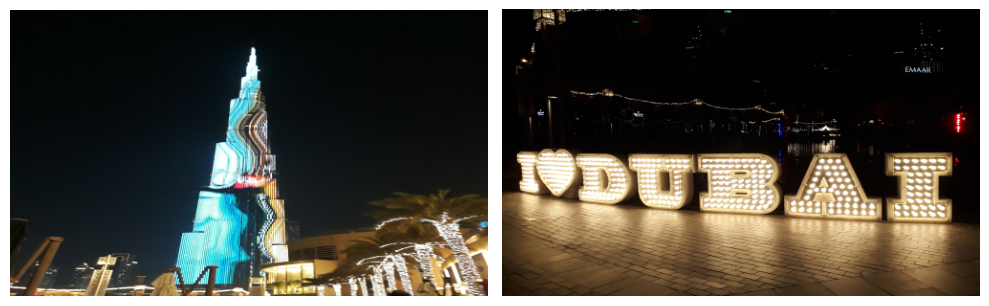

In [27]:
# Load images
img = cv.imread("img/img_1.jpg")
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

img_2 = cv.imread("img/img_2.jpg")
img_2 = cv.cvtColor(img_2, cv.COLOR_BGR2RGB)

# Resize images
dim = (500, 300)
img = resize_image(img, dim)
img_2 = resize_image(img_2, dim)

# Show image comparison
show_img_compar(img, img_2)


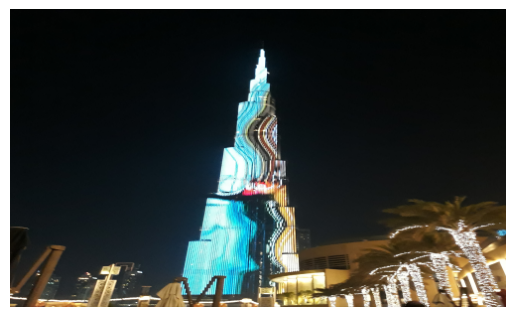

In [28]:
# Function to handle the button click event
def on_button_clicked(b):
    clear_output()
    
    # Call transfer_colors function using img and img_2
    transfer_img = transfer_colors(img, img_2)
    
    # Display the transferred image
    plt.imshow(transfer_img)
    plt.axis('off')
    plt.show()

# Create a button widget
button = widgets.Button(description="Run transfer_colors")

# Attach the on_button_clicked function to the button's click event
button.on_click(on_button_clicked)

# Display the button
display(button)

In [ ]:
# Perform KMeans clustering
n_clusters = 3
clt_1 = perform_kmeans_clustering(img, n_clusters)
clt_2 = perform_kmeans_clustering(img_2, n_clusters)

# Show image comparison
show_img_compar(img, img_2)

# Isolate color in the first image
isolate_color(clt_1.labels_, clt_1.cluster_centers_, 2, 1, dim)

# Transfer colors from the first image to the second
transfer_img = transfer_colors(clt_2.labels_, clt_1.cluster_centers_)

# Save the transfer result
save_image(transfer_img, "Transfer.png")